In [2]:
! pip install tensorflow opencv-python matplotlib scikit-learn scikit-image

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Verification
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import sklearn
import skimage

import os
import random
import numpy as np

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("Scikit-Learn:", sklearn.__version__)
print("Scikit-Image:", skimage.__version__)

TensorFlow: 2.20.0
OpenCV: 4.13.0
Scikit-Learn: 1.8.0
Scikit-Image: 0.26.0


In [4]:
plt.imshow??

Signature:
plt.imshow(
    X: 'ArrayLike | PIL.Image.Image',
    cmap: 'str | Colormap | None' = None,
    norm: 'str | Normalize | None' = None,
    *,
    aspect: "Literal['equal', 'auto'] | float | None" = None,
    interpolation: 'str | None' = None,
    alpha: 'float | ArrayLike | None' = None,
    vmin: 'float | None' = None,
    vmax: 'float | None' = None,
    colorizer: 'Colorizer | None' = None,
    origin: "Literal['upper', 'lower'] | None" = None,
    extent: 'tuple[float, float, float, float] | None' = None,
    interpolation_stage: "Literal['data', 'rgba', 'auto'] | None" = None,
    filternorm: 'bool' = True,
    filterrad: 'float' = 4.0,
    resample: 'bool | None' = None,
    url: 'str | None' = None,
    data=None,
    **kwargs,
) -> 'AxesImage'
Docstring:
Display data as an image, i.e., on a 2D regular raster.

The input may either be actual RGB(A) data, or 2D scalar data, which
will be rendered as a pseudocolor image. For displaying a grayscale
image, set up the col

In [5]:
from tensorflow.keras.models import Model 
from tensorflow.keras.layers import Layer, Conv2D, MaxPooling2D, Input, Flatten #Dense, Dropout, BatchNormalization
import tensorflow as tf 

In [6]:
# Model (inputs=[inputimage, verification_image], outputs=[1, 0])

In [7]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [8]:
len(gpus)


0

In [9]:
gpus

[]

In [10]:
# I tried to work with the GPU but it seems that it is not being detected. I will continue with the CPU for now. 
# TensorFlow's GPU support on native Windows was effectively dropped after TensorFlow 2.10.

Create Folder Structures
--------

In [5]:
# Setup Paths
POS_PATH = os.path.join('data', 'positive')
NEG_PATH = os.path.join('data', 'negative')
ANC_PATH = os.path.join('data', 'anchor')

In [12]:
POS_PATH

'data\\positive'

In [15]:
# Create folders
os.makedirs(POS_PATH)
os.makedirs(NEG_PATH)
os.makedirs(ANC_PATH)

FileExistsError: [WinError 183] Impossible de créer un fichier déjà existant: 'data\\positive'

Collect Positives And Anchors 
---------

In [ ]:
# Uncompress the dataset 'Labelled Faces in the Wild'
! tar -xf archive.zip

In [24]:
# Moving LFW Images to the folder : data/negative
for directory in os.listdir(r'lfw-deepfunneled/lfw-deepfunneled'):
    for file in os.listdir(os.path.join(os.path.join(r'lfw-deepfunneled/lfw-deepfunneled', directory))):
        EX_PATH = os.path.join(r'lfw-deepfunneled/lfw-deepfunneled', directory, file)
        NEW_PATH = os.path.join(NEG_PATH, file)
        os.replace(EX_PATH, NEW_PATH)


In [1]:
# Importing uuid library to generate unique names for the images captured from the webcam
import uuid

In [28]:
uuid.uuid1()

UUID('b8375fd2-6f0d-11f1-bb9c-c018034eab96')

In [ ]:
os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))

In [6]:
# Collecte Positive and Anchor Classes

cap = cv2.VideoCapture(0) # Establish a connection to the webcam
while cap.isOpened(): 
    ret, frame = cap.read()
    if not ret:
        break
    
    frame = frame[120:120+250, 200:200+250, : ] # Crop the image to a square shape (250x250) from the center of the frame
    
    # Collect Anchors
    if cv2.waitKey(1) & 0xFF == ord('a'):
        imagename = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1())) # Generate a unique name for the image
        cv2.imwrite(imagename, frame) # Save the image to the anchor folder
    
    # Collect Positives 
    if cv2.waitKey(1) & 0xFF == ord('p'):   
        imagename = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1())) # Generate a unique name for the image
        cv2.imwrite(imagename, frame) # Save the image to the positive folder   
    
    
    
    cv2.imshow('Image Collection', frame) # Show image back to screen
    
    # Breaking gracefully
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release() # Realease the webcam
cv2.destroyAllWindows() # Close(destry) the image show frame

In [ ]:

for i in range(5):
    cap = cv2.VideoCapture(i)
    if cap.isOpened():
        print(f"Camera found at index {i}")
    else:
        print(f"No camera at index {i}")
    cap.release()
    
# To know the camera in wich index so we can choose the right number(in VideoCapture)

Camera found at index 0
No camera at index 1
No camera at index 2
No camera at index 3
No camera at index 4


In [ ]:
frame

array([[[ 78, 105, 109],
        [ 79, 106, 103],
        [ 83, 111,  96],
        ...,
        [162, 168, 147],
        [158, 165, 141],
        [156, 163, 138]],

       [[ 79, 105, 106],
        [ 79, 106, 101],
        [ 82, 109,  93],
        ...,
        [163, 167, 149],
        [160, 165, 144],
        [160, 164, 142]],

       [[ 78, 102,  98],
        [ 77, 101,  93],
        [ 81, 106,  90],
        ...,
        [166, 164, 153],
        [166, 164, 150],
        [165, 163, 148]],

       ...,

       [[ 45,   0,  27],
        [ 39,   1,  33],
        [ 23,   3,  36],
        ...,
        [187, 187, 173],
        [187, 187, 173],
        [186, 186, 172]],

       [[ 56,   1,  34],
        [ 56,  15,  43],
        [ 39,  22,  42],
        ...,
        [192, 186, 174],
        [191, 185, 172],
        [190, 184, 171]],

       [[ 71,  12,  46],
        [ 76,  34,  59],
        [ 61,  47,  58],
        ...,
        [195, 185, 174],
        [194, 185, 173],
        [193, 184, 171]]

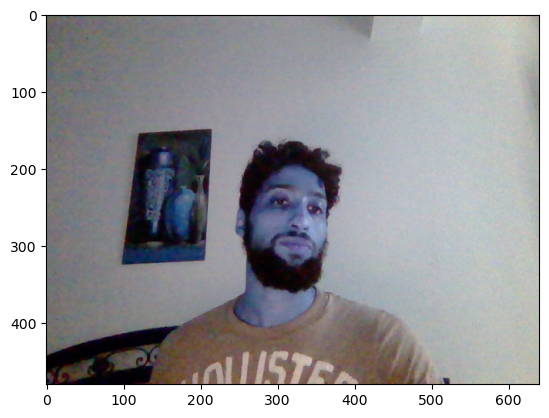

In [ ]:
plt.imshow(frame)

In [ ]:
frame.shape # We must reshape it to same shape as the LFW dataset photos shape , it's called "Resizing" 

(480, 640, 3)

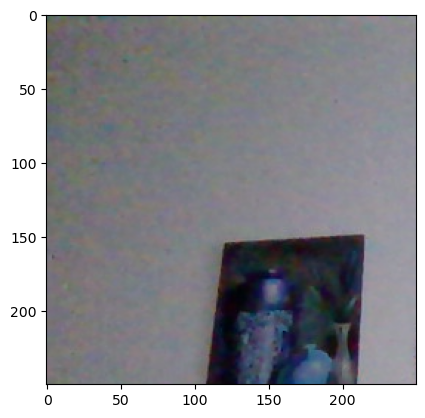

In [ ]:
frame[:250, :250, : ] # Black out the top left corner of the image
plt.imshow(frame[:250, :250, : ]) # Show the blacked out image

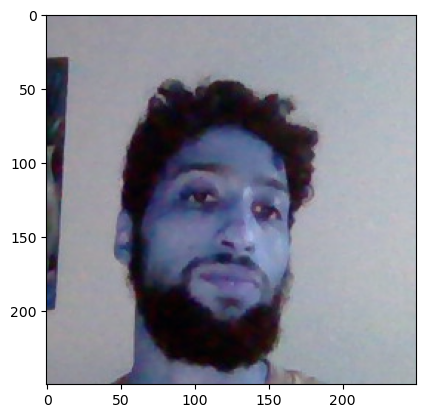

In [ ]:
plt.imshow(frame[120:120+250, 200:200+250, : ]) 